In [616]:
from langgraph.graph import add_messages
from langchain_core.messages import BaseMessage
from typing import TypedDict, Annotated, Sequence, List, Optional, Dict

class AgentState(TypedDict):
    dialogue: Optional[Dict[str, List[str | int | None]]]
    next_speaker: Optional[str]
    members: Optional[List[str]]
    team_description: Optional[List[str]]

In [617]:
from langchain_core.messages import SystemMessage
from langchain_core.prompts import (
    ChatPromptTemplate,
    MessagesPlaceholder,
    HumanMessagePromptTemplate,
    SystemMessagePromptTemplate,
)

orkestrator_prompt = ChatPromptTemplate.from_messages(
    [
        (
            'system',
            'Ты - ведущий беседы, задача которого заключается в управлении разговором между учасниками команды, каждый учасник должен как минимум рассказать что он сделал и планирует сделать, но так же могут задавать вопросы'
            'Следи за тем кто кому передал слово, и задал вопрос'
        ),
        (
            'placeholder',
            '{dialogue}'
        ),
        (
            'placeholder',
            '{team_description}'
        ),
        (
            'user',
            'Учитывая приведённый выше диалог, кто должен говорить следующим? '
            'Выбери один из следующих вариантов: {options}'
            'Выбирай End только если все вопросы были обсуждены и все рассказали о своих задачах'
        ),
    ]
)

person_prompt = ChatPromptTemplate.from_messages(
    [
        (
            'system',
            ' Тебя зовут {name}, ты находишься на утренней встрече, где обсуждается проделанная работа за прошлый рабочий день и задачи на сегодня,'
            ' а так же задаются вопросы другим людям, если они есть.'
            ' Твоя роль в команде {role} ты {time_in_team}.'
            ' Ты {personality} и твои обязанности {duties}'
            ' Ты {completed_tasks}. планируешь сегодня {plans_for_today} '
            ' Не забывай о том что нужно общаться прилично'
        ),
        (
            'placeholder',
            '{dialogue}'
        ),
        (
            'placeholder',
            '{team_description}'
        ),
        (
            'user',
            ' Учитывая Диалог и состав команды'
            ' В первый раз, когда тебе передали слово ты должен рассказать что сделал, потом что планируешь сделать, но если уже говорил, не следует это повторять.'
            ' В конце ты можешь либо задать вопрос кому-то, либо просто передать слово тому кто еще не говорил.'
            ' Если тебе передали слово задавай вопрос или отвечай на вопрос заданый тебе.'
            ' Если больше не хочешь задавать вопросы и все учасники из списка ответили на заданые им вопросы и о проделанной работе, предлагай прощаться'
        ),
    ]
)



In [618]:
from functools import lru_cache
from langchain_openai import ChatOpenAI
import random
from pydantic import BaseModel
from typing import TypedDict, Annotated, Sequence, List, Optional, Dict, Literal


@lru_cache(maxsize=1)
def _get_model(model_name: str):
    if model_name == "openai":
        model = ChatOpenAI(temperature=1, model_name="gpt-4o")
    else:
        raise ValueError(f"Unsupported model type: {model_name}")
    return model


def get_route_model(options_names: list[str]):
    class Route(BaseModel):
        """Выбери следующую роль"""
        next: Literal[*options_names] 

    return Route

def make_team_description(state):
    'Init Members'
    employees = {}
    persons = read_persons()
    for name, data in persons.items():
        employees[name] = EmployeeBase(**data)        
    state['team_description'] = [f'{person.name} -- {person.role}, который {person.duties}' for person in employees.values()]
    return state

def Orkestrator(state):
    '''Orkestrator'''

    llm = _get_model(model_name="openai")

    partial_client_choose_prompt = orkestrator_prompt.partial(
        options=str(state['members'])
    )
    route_model = get_route_model(state['members'])
    
    A = partial_client_choose_prompt | llm.with_structured_output(route_model)
    state['next_speaker'] = A.invoke({'dialogue': state['dialogue'],'team_description': state['team_description']}).next
    
    print(f'Дальше говорит {state["next_speaker"]}')
    
    return state


def choose_person(state):
    return state['next_speaker']


In [619]:
from pydantic import BaseModel
from functools import lru_cache
import json
import os

class EmployeeBase(BaseModel):
    name: str
    role: str
    time_in_team: str
    personality: str
    duties: str
    completed_tasks: str
    plans_for_today: str

    def talker(self, state):
        print(f'{self.__doc__} говорит:\n')
        
        llm = _get_model(model_name="openai")
        descr = {k: v for k, v in self.__dict__.items() if not k.startswith('__')}
        
        partial_client_choose_prompt = person_prompt.partial(**descr)

        B = partial_client_choose_prompt | llm

        answ = B.invoke({'dialogue': state['dialogue'],
                         'team_description': state['team_description']})
        
        print(f"({self.__doc__}){answ.content}")
        state['dialogue'].append(f"({self.__doc__}) {answ.content}")
        return state
    

def read_persons():
    with open(os.path.join('ai_daily','utils','data','persons.json'), 'r', encoding="utf-8") as file:
        persons = json.load(file)
    
    return persons


def make_persons():
    employees = {}
    persons = read_persons()
    for name, data in persons.items():
        employees[name] = EmployeeBase(**data)
    for name, class_ in employees.items():
        class_.__doc__ = name
    return employees

def End_of_chat(state):
    'End of chat'
    return state


In [620]:
from typing import TypedDict, Literal

import json

from langgraph.graph import StateGraph, END

members = make_persons()

graph_builder = StateGraph(AgentState)

graph_builder.add_node(make_team_description.__doc__, make_team_description)
graph_builder.add_edge(make_team_description.__doc__, Orkestrator.__doc__)
graph_builder.add_node(End_of_chat.__doc__, End_of_chat)
graph_builder.add_node(Orkestrator.__doc__, Orkestrator)


for_cond = {'End': End_of_chat.__doc__}
for name, class_ in members.items():
    graph_builder.add_node(name, class_.talker)
    graph_builder.add_edge(name, Orkestrator.__doc__)
    for_cond[name] = name

graph_builder.add_conditional_edges(
    Orkestrator.__doc__,
    choose_person,
    for_cond,
)


graph_builder.set_entry_point(make_team_description.__doc__)
graph_builder.set_finish_point(End_of_chat.__doc__)

graph = graph_builder.compile()


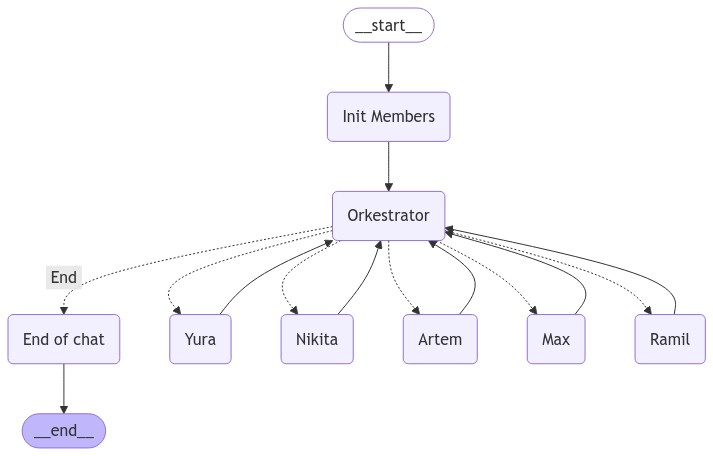

In [621]:
graph

In [622]:
initial_state = AgentState(
    members = ['Yura', 'Nikita', 'Artem', 'Max','Ramil','End'],
    dialogue=[],
)
graph.invoke(initial_state)

Дальше говорит Yura
Yura говорит:

(Yura)Вчера я составил ТЗ на разметку для оценки качества функций оценки корректности ответа КМ на вопрос клиента. Сегодня планирую составить ТЗ на разметку для оценки качества функции завершения диалога с клиентом. 

Рамиль, как продвигаются дела с заказчиками? Какие у нас сейчас основные приоритеты по обратной связи?
Дальше говорит Ramil
Ramil говорит:

(Ramil)Вчера я активно занимался коммуникациями с нашими заказчиками, выяснял их текущие потребности и собирал обратную связь по Tender Scaner. Мы получили несколько важных комментариев, которые стоит учесть в работе. Основная задача на сегодня — провести серию звонков с заказчиками для уточнения их комментариев и согласования дальнейших шагов. 

Yura, какой статус по отзывам, которые вы собирали для тренажера Клиентских менеджеров? Есть ли что-то, что нужно учесть при следующих созвонах с заказчиками?
Дальше говорит Yura
Yura говорит:

(Yura)На данный момент по отзывам, которые мы собирали для трена

{'dialogue': ['(Yura) Вчера я составил ТЗ на разметку для оценки качества функций оценки корректности ответа КМ на вопрос клиента. Сегодня планирую составить ТЗ на разметку для оценки качества функции завершения диалога с клиентом. \n\nРамиль, как продвигаются дела с заказчиками? Какие у нас сейчас основные приоритеты по обратной связи?',
  '(Ramil) Вчера я активно занимался коммуникациями с нашими заказчиками, выяснял их текущие потребности и собирал обратную связь по Tender Scaner. Мы получили несколько важных комментариев, которые стоит учесть в работе. Основная задача на сегодня — провести серию звонков с заказчиками для уточнения их комментариев и согласования дальнейших шагов. \n\nYura, какой статус по отзывам, которые вы собирали для тренажера Клиентских менеджеров? Есть ли что-то, что нужно учесть при следующих созвонах с заказчиками?',
  '(Yura) На данный момент по отзывам, которые мы собирали для тренажера Клиентских менеджеров, мы получили определенное количество положительн

In [ ]:
[2]+[3]